In [1]:
# colours = [["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
#            ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
#            ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)], 
#            ["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
#            ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)]]
# r1 = ["#E1EFF2" for x in range(width)]
# r2 = ["#F4F9F9" for x in range(width)]
# colours_appended = []
# for width, height in 

###### Imports and Settings

In [2]:
import pandas as pd
import numpy as np
import requests
#import io
import pickle
import dataframe_image as dfi
from collections import deque
from functools import reduce
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import StrMethodFormatter
from matplotlib import rcParams
import matplotlib as mpl
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 150)
pd.options.mode.chained_assignment = None  # default='warn'

In [3]:
#STYLIN' CONTROLS

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
BIGGEST_SIZE = 18

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('axes', titlesize=BIGGEST_SIZE)  # fontsize of the figure title

rcParams['font.family'] = 'calibri'

COLOR = '#00263E'
mpl.rcParams['text.color'] = COLOR
mpl.rcParams['axes.labelcolor'] = COLOR
mpl.rcParams['axes.labelpad'] = 15
mpl.rcParams['axes.titlepad'] = 20
mpl.rcParams['xtick.color'] = COLOR
mpl.rcParams['ytick.color'] = COLOR

In [4]:
def prettypercentchange(x, y):
    return round((x - y)*100/y, 1).astype(str)+'%'
def mathpercentchange(x, y):
    return round((x - y)/y, 1)

In [5]:
data = pd.read_csv('../../data/Geography Specific Output/GallatinTables.csv')
data.head()

NAME  Population 2000  Male Under 5 2000  Female Under 5 2000  Male 5 to 14 2000  Female 5 to 14 2000  Male 15 to 24 2000  \
0       Tennessee        5689283.0           192283.0             182597.0           406102.0             384866.0            397300.0   
1     GNRC Region        1481223.0            53434.0              50327.0           107405.0             101540.0            108166.0   
2   Sumner County         130449.0             4567.0               4266.0             9939.0               9347.0              8615.0   
3        Gallatin          23230.0              844.0                856.0             1636.0               1545.0              1617.0   
4  Goodlettsville          13780.0              466.0                452.0              945.0                880.0               831.0   

   Female 15 to 24 2000  Male 5 to 9 2000  Female 5 to 9 2000  Male 10 to 14 2000  Female 10 to 14 2000  Male 15 to 17 2000  Female 15 to 17 2000  \
0              384229.0          203330.0            192483.0            202772.0              192383.0            120149.0              112524.0   
1              104423.0           54119.0             51246.0             53286.0               50294.0             31147.0               29227.0   
2                8088.0            4862.0              4574.0              5077.0                4773.0              3242.0                2976.0   
3                1583.0             818.0               748.0               818.0                 797.0               517.0                 497.0   
4                 825.0             454.0               470.0               491.0                 410.0               273.0                 245.0   

   Male 18 to 24 2000  Female 18 to 24 2000  Male 25 to 34 2000  Female 25 to 34 2000  Male 35 to 44 2000  Female 35 to 44 2000  Male 45 to 54 2000  \
0            277151.0              271705.0            409068.0              406833.0            442911.0              459616.0            384928.0   
1             77019.0               75196.0            117594.0              115950.0            123366.0              127864.0             98776.0   
2              5373.0                5112.0              8794.0                9036.0             10750.0               11468.0              9378.0   
3              1100.0                1086.0              1674.0                1696.0              1687.0                1823.0              1461.0   
4               558.0                 580.0              1010.0                1023.0              1046.0                1239.0               924.0   

   Female 45 to 54 2000  Male 55 to 64 2000  Female 55 to 64 2000  Male 65 to 74 2000  Female 65 to 74 2000  Male 75 to 84 2000  \
0              401988.0            255801.0              277450.0            170474.0              212378.0             89565.0   
1              101577.0             58578.0               63058.0             36414.0               45558.0             18499.0   
2                9577.0              6168.0                6540.0              3524.0                4174.0              1719.0   
3                1517.0               968.0                1145.0               667.0                 888.0               365.0   
4                1038.0               683.0                 775.0               395.0                 486.0               209.0   

   Female 75 to 84 2000  Male 85 and Older 2000  Female 85 and Older 2000  Age:Under 5 2000  Age %:Under 5 2000  Age:5 to 9 2000  Age%:5 to 9 2000  \
0              149429.0                 21843.0                   59622.0          374880.0            6.589231         395813.0          6.957168   
1               31208.0                  4578.0                   12908.0          103761.0            7.005090         105365.0          7.113379   
2                2868.0                   422.0                    1209.0            8833.0            6.771229           9436.0          7.23347

In [6]:
data = data.set_index('NAME')
new_index = ['US', 'Tennessee', 'GNRC Region', 'Sumner County', 'Gallatin', 'Goodlettsville', 'Millersville', 
             'Portland', 'White House', 'Hendersonville', 'Westmoreland']
data = data.reindex(new_index)
data = data.reset_index()

# Population  
## Total Population 2000 to 2020

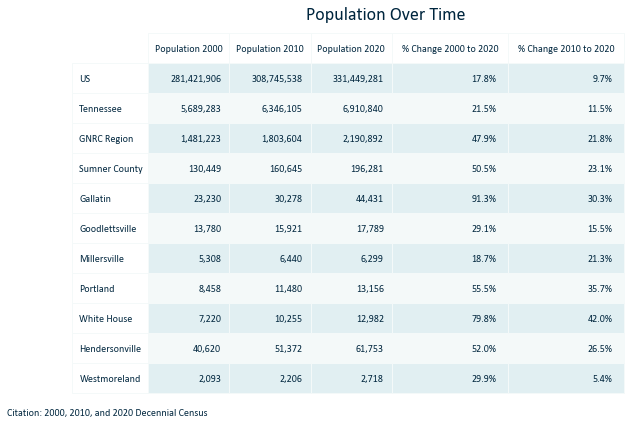

In [7]:
citation = 'Citation: 2000, 2010, and 2020 Decennial Census'
title = 'Population Over Time'
width = 5
geographycount = 11
colours = [["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)]]
colcolours = ['None' for x in range(width)]
rowcolours = ["None" for x in range(geographycount)]
#title height
y = 1.3
#citation placement
c1 = .1
c2 = -.2
#initiate figure and hide axes
fig, ax = plt.subplots()
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')
#data and formatting
df_temp = data.set_index('NAME')
df_temp = df_temp[['Population 2000', 'Population 2010', 'Population 2020']]
df_temp['% Change 2000 to 2020'] = prettypercentchange(df_temp['Population 2020'], df_temp['Population 2000'])
df_temp['% Change 2010 to 2020'] = prettypercentchange(df_temp['Population 2010'], df_temp['Population 2000'])
df_temp.update(df_temp[['Population 2000', 'Population 2010', 'Population 2020']].applymap('{:,.0f}'.format))
#initiate table and set parameters
table = ax.table(cellText = df_temp.values, colLabels = df_temp.columns, rowLabels = df_temp.index, loc = 'center', cellColours = colours, colColours = colcolours, 
                cellLoc = 'right', rowLoc = 'left', rowColours = rowcolours)
ax.set_title(label = title, y = y)
table.scale(2, 2.5) #table scaling
for c in table.get_children():
    c.set_edgecolor('#F4F9F9')
#display
table.auto_set_column_width(col=list(range(len(df_temp.columns))))
fig.text(c1, c2, citation, ha='right')
#display
fig.savefig('gallatinfigstables/populationtable.png', bbox_inches='tight', dpi = 500)
plt.show();

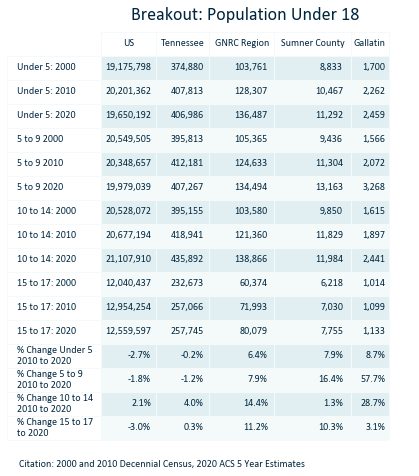

In [162]:
#detail under 18 for current year, mid year, oldest year and percent change from mid year
df_temp = data.loc[(data['NAME']=='US')|(data['NAME']=='Tennessee')|(data['NAME']=='GNRC Region')|
                   (data['NAME']=='Sumner County')|(data['NAME']=='Gallatin')]
df_temp = df_temp[['NAME', 'Age:Under 5 2000', 'Age:Under 5 2010', 'Age:Under 5 2020',
                   'Age:5 to 9 2000', 'Age:5 to 9 2010', 'Age:5 to 9 2020',
                   'Age:10 to 14 2000', 'Age:10 to 14 2010', 'Age:10 to 14 2020',
                   'Age:15 to 17 2000', 'Age:15 to 17 2010', 'Age:15 to 17 2020']]
df_temp['% Change Under 5\n2010 to 2020'] = prettypercentchange(df_temp['Age:Under 5 2020'], df_temp['Age:Under 5 2010'])
df_temp['% Change 5 to 9 \n2010 to 2020'] = prettypercentchange(df_temp['Age:5 to 9 2020'], df_temp['Age:5 to 9 2010'])
df_temp['% Change 10 to 14 \n2010 to 2020'] = prettypercentchange(df_temp['Age:10 to 14 2020'], df_temp['Age:10 to 14 2010'])
df_temp['% Change 15 to 17 \nto 2020'] = prettypercentchange(df_temp['Age:15 to 17 2020'], df_temp['Age:15 to 17 2010'])
df_temp = df_temp.rename(columns = {'Age:Under 5 2000':'Under 5: 2000', 'Age:Under 5 2010':'Under 5: 2010', 'Age:Under 5 2020':'Under 5: 2020',
                                    'Age:5 to 9 2000':'5 to 9 2000', 'Age:5 to 9 2010':'5 to 9 2010', 'Age:5 to 9 2020':'5 to 9 2020',
                                    'Age:10 to 14 2000':'10 to 14: 2000', 'Age:10 to 14 2010':'10 to 14: 2010', 'Age:10 to 14 2020':'10 to 14: 2020',
                                    'Age:15 to 17 2000':'15 to 17: 2000', 'Age:15 to 17 2010':'15 to 17: 2010', 'Age:15 to 17 2020':'15 to 17: 2020'})
df_temp.update(df_temp[['Under 5: 2000','Under 5: 2010','Under 5: 2020','5 to 9 2000','5 to 9 2010','5 to 9 2020','10 to 14: 2000','10 to 14: 2010', 
                        '10 to 14: 2020','15 to 17: 2000','15 to 17: 2010','15 to 17: 2020']].applymap('{:,.0f}'.format))
df_temp = df_temp.set_index('NAME')
df_temp = df_temp.transpose()
citation = 'Citation: 2000 and 2010 Decennial Census, 2020 ACS 5 Year Estimates'
title = 'Breakout: Population Under 18'
width = 5
indexcount = 16
colours = [["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)], 
           ["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)]]
colcolours = ['None' for x in range(width)]
rowcolours = ["None" for x in range(indexcount)]
fig, ax = plt.subplots() #initiate figure and hide axes
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')
#initiate table and set parameters
table = ax.table(cellText = df_temp.values, colLabels = df_temp.columns, rowLabels = df_temp.index, loc = 'center', cellColours = colours, colColours = colcolours, 
                cellLoc = 'right', rowLoc = 'left', rowColours = rowcolours)
table.scale(2, 2) #table scaling
table.auto_set_column_width(col=list(range(len(df_temp.columns))))#optimize column width
ax.set_title(label = title, y = 1.4) #title and title height
for c in table.get_children(): #edge colors
    c.set_edgecolor('#F4F9F9')
fig.text(0.65, -.3, citation, ha='right') #citation placement
fig.savefig('gallatinfigstables/breakoutagesunder18.png', bbox_inches='tight', dpi = 500) #save figure and set dpi
plt.show(); #show figure and close out

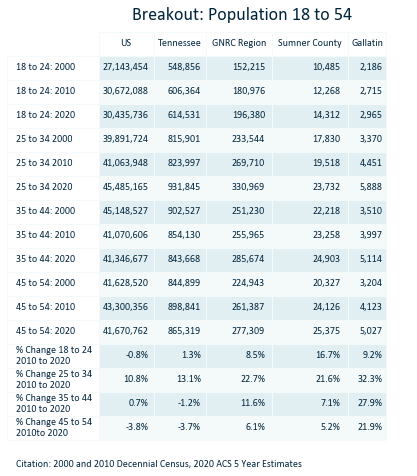

In [163]:
#18 to 54
df_temp = data.loc[(data['NAME']=='US')|(data['NAME']=='Tennessee')|(data['NAME']=='GNRC Region')|
                   (data['NAME']=='Sumner County')|(data['NAME']=='Gallatin')]
df_temp = df_temp[['NAME', 'Age:18 to 24 2000', 'Age:18 to 24 2010', 'Age:18 to 24 2020',
                   'Age:25 to 34 2000', 'Age:25 to 34 2010', 'Age:25 to 34 2020',
                   'Age:35 to 44 2000', 'Age:35 to 44 2010', 'Age:35 to 44 2020',
                   'Age:45 to 54 2000', 'Age:45 to 54 2010', 'Age:45 to 54 2020']]
df_temp['% Change 18 to 24\n2010 to 2020'] = prettypercentchange(df_temp['Age:18 to 24 2020'], df_temp['Age:18 to 24 2010'])
df_temp['% Change 25 to 34\n2010 to 2020'] = prettypercentchange(df_temp['Age:25 to 34 2020'], df_temp['Age:25 to 34 2010'])
df_temp['% Change 35 to 44\n2010 to 2020'] = prettypercentchange(df_temp['Age:35 to 44 2020'], df_temp['Age:35 to 44 2010'])
df_temp['% Change 45 to 54\n2010to 2020'] = prettypercentchange(df_temp['Age:45 to 54 2020'], df_temp['Age:45 to 54 2010'])
df_temp = df_temp.rename(columns = {'Age:18 to 24 2000':'18 to 24: 2000', 'Age:18 to 24 2010':'18 to 24: 2010', 'Age:18 to 24 2020':'18 to 24: 2020',
                                    'Age:25 to 34 2000':'25 to 34 2000', 'Age:25 to 34 2010':'25 to 34 2010', 'Age:25 to 34 2020':'25 to 34 2020',
                                    'Age:35 to 44 2000':'35 to 44: 2000', 'Age:35 to 44 2010':'35 to 44: 2010', 'Age:35 to 44 2020':'35 to 44: 2020',
                                    'Age:45 to 54 2000':'45 to 54: 2000', 'Age:45 to 54 2010':'45 to 54: 2010', 'Age:45 to 54 2020':'45 to 54: 2020'})
df_temp.update(df_temp[['18 to 24: 2000','18 to 24: 2010','18 to 24: 2020','25 to 34 2000','25 to 34 2010','25 to 34 2020','35 to 44: 2000','35 to 44: 2010', 
                        '35 to 44: 2020','45 to 54: 2000','45 to 54: 2010','45 to 54: 2020']].applymap('{:,.0f}'.format))
df_temp = df_temp.set_index('NAME').transpose()
citation = 'Citation: 2000 and 2010 Decennial Census, 2020 ACS 5 Year Estimates'
title = 'Breakout: Population 18 to 54'
width = 5
indexcount = 16
colours = [["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)], 
           ["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)]]
colcolours = ['None' for x in range(width)]
rowcolours = ["None" for x in range(indexcount)]
fig, ax = plt.subplots() #initiate figure and hide axes
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')
#initiate table and set parameters
table = ax.table(cellText = df_temp.values, colLabels = df_temp.columns, rowLabels = df_temp.index, loc = 'center', cellColours = colours, colColours = colcolours, 
                cellLoc = 'right', rowLoc = 'left', rowColours = rowcolours)
table.scale(1, 2) #table scaling (x value overwritten, y value for row height)
table.auto_set_column_width(col=list(range(len(df_temp.columns))))#optimize column width
ax.set_title(label = title, y = 1.4) #title and title height
for c in table.get_children(): #edge colors
    c.set_edgecolor('#F4F9F9')
fig.text(0.65, -.3, citation, ha='right') #citation placement
fig.savefig('gallatinfigstables/breakoutages18to54.png', bbox_inches='tight', dpi = 500) #save figure and set dpi
plt.show(); #show figure and close out

In [211]:
from matplotlib.font_manager import FontProperties

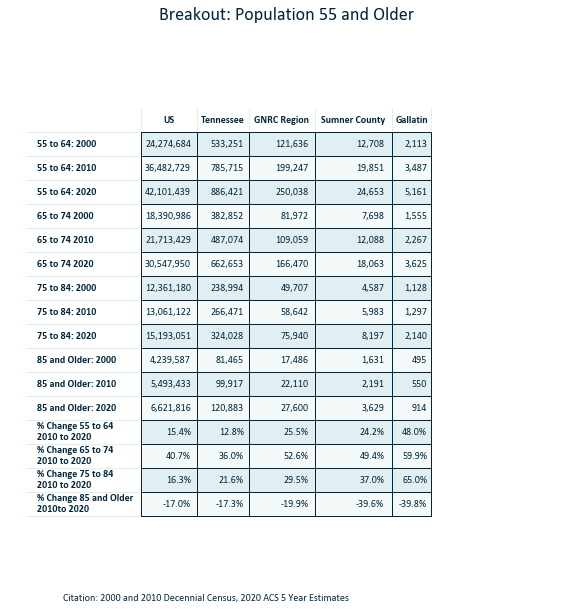

In [231]:
#55 and Over
df_temp = data.loc[(data['NAME']=='US')|(data['NAME']=='Tennessee')|(data['NAME']=='GNRC Region')|
                   (data['NAME']=='Sumner County')|(data['NAME']=='Gallatin')]
df_temp = df_temp[['NAME', 'Age:55 to 64 2000', 'Age:55 to 64 2010', 'Age:55 to 64 2020',
                   'Age:65 to 74 2000', 'Age:65 to 74 2010', 'Age:65 to 74 2020',
                   'Age:75 to 84 2000', 'Age:75 to 84 2010', 'Age:75 to 84 2020',
                   'Age:85 and Older 2000', 'Age:85 and Older 2010', 'Age:85 and Older 2020']]
df_temp['% Change 55 to 64\n2010 to 2020'] = prettypercentchange(df_temp['Age:55 to 64 2020'], df_temp['Age:55 to 64 2010'])
df_temp['% Change 65 to 74\n2010 to 2020'] = prettypercentchange(df_temp['Age:65 to 74 2020'], df_temp['Age:65 to 74 2010'])
df_temp['% Change 75 to 84\n2010 to 2020'] = prettypercentchange(df_temp['Age:75 to 84 2020'], df_temp['Age:75 to 84 2010'])
df_temp['% Change 85 and Older\n2010to 2020'] = prettypercentchange(df_temp['Age:85 and Older 2010'], df_temp['Age:85 and Older 2020'])
df_temp = df_temp.rename(columns = {'Age:55 to 64 2000':'55 to 64: 2000', 'Age:55 to 64 2010':'55 to 64: 2010', 'Age:55 to 64 2020':'55 to 64: 2020',
                                    'Age:65 to 74 2000':'65 to 74 2000', 'Age:65 to 74 2010':'65 to 74 2010', 'Age:65 to 74 2020':'65 to 74 2020',
                                    'Age:75 to 84 2000':'75 to 84: 2000', 'Age:75 to 84 2010':'75 to 84: 2010', 'Age:75 to 84 2020':'75 to 84: 2020',
                                    'Age:85 and Older 2000':'85 and Older: 2000', 'Age:85 and Older 2010':'85 and Older: 2010', 'Age:85 and Older 2020':'85 and Older: 2020'})
df_temp.update(df_temp[['55 to 64: 2000','55 to 64: 2010','55 to 64: 2020','65 to 74 2000','65 to 74 2010','65 to 74 2020','75 to 84: 2000','75 to 84: 2010', 
                        '75 to 84: 2020','85 and Older: 2000','85 and Older: 2010','85 and Older: 2020']].applymap('{:,.0f}'.format))
df_temp = df_temp.set_index('NAME').transpose()
citation = 'Citation: 2000 and 2010 Decennial Census, 2020 ACS 5 Year Estimates'
title = 'Breakout: Population 55 and Older'
width = 5
indexcount = 16
colours = [["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)], 
           ["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)]]
colcolours = ['None' for x in range(width)]
rowcolours = ["None" for x in range(indexcount)]
fig, ax = plt.subplots(figsize = (10, 5)) #initiate figure and hide axes
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')
row_headers = df_temp.index
column_headers = df_temp.columns
#initiate table and set parameters
table = ax.table(cellText = df_temp.values, colLabels = column_headers, rowLabels = row_headers, loc = 'center', cellColours = colours, colColours = colcolours, 
                cellLoc = 'right', rowLoc = 'left', rowColours = rowcolours)
table.scale(1, 2) #table scaling (x value overwritten, y value for row height)
table.auto_set_column_width(col=list(range(len(df_temp.columns))))#optimize column width - this overrides the value in table.scale(x)
ax.set_title(label = title, y = 1.5) #title and title height
# for c in table.get_children(): #edge colors
#     c.set_edgecolor('#F4F9F9')
for cell in table.get_children():
    cell_text = cell.get_text().get_text()
    #cell.set_edgecolor('#F4F9F9')
    if cell_text not in row_headers\
    and cell_text not in column_headers:
        cell.set_edgecolor('#00263E')
    else:
        cell.set(edgecolor='#E1EFF2')
for cell in table.get_children():
    cell_text = cell.get_text().get_text()
    if cell_text in column_headers:
        cell.visible_edges = 'vertical'
    elif cell_text in row_headers:
        cell.visible_edges = 'horizontal'
for cell in table.get_children():
    cell_text = cell.get_text().get_text()
    if cell_text in row_headers\
    or cell_text in column_headers:
        cell.set_text_props(fontproperties=FontProperties(weight='bold'))
fig.text(.6, -.3, citation, ha='right') #citation placement
fig.savefig('gallatinfigstables/breakoutages55andolder.png', bbox_inches='tight', dpi = 500) #save figure and set dpi
plt.show(); #show figure and close out

In [ ]:
celledges = 
for cell in table.get_children():
    cell_text = cell.get_text().get_text()
    #cell.set_edgecolor('#F4F9F9')
    if cell_text not in row_headers\
    and cell_text not in column_headers:
        cell.set_edgecolor('#00263E')
    else:
        cell.set(edgecolor='#E1EFF2')
for cell in table.get_children():
    cell_text = cell.get_text().get_text()
    if cell_text in column_headers:
        cell.visible_edges = 'vertical'
    elif cell_text in row_headers:
        cell.visible_edges = 'horizontal'
for cell in table.get_children():
    cell_text = cell.get_text().get_text()
    if cell_text in row_headers\
    or cell_text in column_headers:
        cell.set_text_props(fontproperties=FontProperties(weight='bold'))

In [131]:
data.head(3)

,NAME,Population 2000,Male Under 5 2000,Female Under 5 2000,Male 5 to 14 2000,Female 5 to 14 2000,Male 15 to 24 2000,Female 15 to 24 2000,Male 5 to 9 2000,Female 5 to 9 2000,Male 10 to 14 2000,Female 10 to 14 2000,Male 15 to 17 2000,Female 15 to 17 2000,Male 18 to 24 2000,Female 18 to 24 2000,Male 25 to 34 2000,Female 25 to 34 2000,Male 35 to 44 2000,Female 35 to 44 2000,Male 45 to 54 2000,Female 45 to 54 2000,Male 55 to 64 2000,Female 55 to 64 2000,Male 65 to 74 2000,Female 65 to 74 2000,Male 75 to 84 2000,Female 75 to 84 2000,Male 85 and Older 2000,Female 85 and Older 2000,Age:Under 5 2000,Age %:Under 5 2000,Age:5 to 9 2000,Age%:5 to 9 2000,Age:10 to 14 2000,Age%:10 to 14 2000,Age:15 to 17 2000,Age%:15 to 17 2000,Age:18 to 24 2000,Age%:18 to 24 2000,Age:25 to 34 2000,Age%:25 to 34 2000,Age:35 to 44 2000,Age%:35 to 44 2000,Age:45 to 54 2000,Age%:45 to 54 2000,Age:55 to 64 2000,Age%:55 to 64 2000,Age:65 to 74 2000,Age%:65 to 74 2000,Age:75 to 84 2000,Age%:75 to 84 2000,Age:85 and Older 2000,Age%:85 and Older 2000,Age:Under 18 2000,Age%:Under 18 2000,Age:18 to 54 2000,Age%:18 to 54 2000,Age:55 and Older 2000,Age%:55 and Older 2000,Age:65 and Older 2000,Age%:65 and Older 2000,White Alone 2000,White Alone % 2000,Non-White Population: Race 2000,Black or African American Alone 2000,Black or African American Alone % 2000,Black or African American Alone % Non-White Population 2000,American Indian Alaska Native Alone 2000,American Indian Alaska Native Alone % 2000,American Indian Alaska Native Alone % Non-White Population 2000,Asian Alone 2000,Asian Alone % 2000,Asian Alone % Non-White Population 2000,Native Hawaiian Other Pacific Islander Alone 2000,Native Hawaiian Other Pacific Islander Alone % 2000,Native Hawaiian Other Pacific Islander Alone % Non-White Population 2000,Some Other Race Alone 2000,Some Other Race Alone % 2000,Some Other Race Alone % Non-White Population 2000,Two or More Races 2000,Two or More Races % 2000,Two or More Races % Non-White Population 2000,Hispanic or Latino 2000,Hispanic or Latino % 2000,Not Hispanic or Latino 2000,Not Hispanic or Latino % 2000,Minority 2000,Minority % 2000,White Alone Not Hispanic or Latino 2000,White Alone Not Hispanic or Latino % 2000,Total Households 2000,Family Households 2000,Family Households: Married Couple Family 2000,"Household Type%: Family, Married Couple Households 2000",Family Households: Not Married Couple Family 2000,"Household Type%: Family, Not Married Couple Households 2000",Family Households: Not Married Couple: Male no Spouse 2000,Family Households: Not Married Couple: Female no Spouse 2000,Nonfamily Households 2000,Nonfamily Households: Householder Alone 2000,"Household Type%: Nonfamily, Householder Alone 2000",Nonfamily Households: Householder not Alone 2000,"Household Type%: Nonfamily, Householder Not Alone 2000",Average Household Size 2000,Occupancy:Total Households 2000,Occupancy:Occupied Units 2000,Occupancy%:Occupied Units 2000,Occupancy:Vacant Units 2000,Occupancy%:Vacant Units 2000,Tenure:Total Households 2000,Tenure:Owners 2000,Tenure%:Owners 2000,Tenure:Renters 2000,Tenure%:Renters 2000,Median Household Income 2000,HHIncome:Total Households 2000,"HHIncome:Less than 10,000 2000","HHIncome%:Less than 10,000 2000","HHIncome:10 to 14,999 2000","HHIncome%:10 to 14,999 2000","HHIncome:15 to 19,999 2000","HHIncome%:15 to 19,999 2000","HHIncome:20 to 24,999 2000","HHIncome%:20 to 24,999 2000","HHIncome:25 to 29,999 2000","HHIncome%:25 to 29,999 2000","HHIncome:30 to 34,999 2000","HHIncome:%30 to 34,999 2000","HHIncome:35 to 39,999 2000","HHIncome%:35 to 39,999 2000","HHIncome:40 to 44,999 2000","HHIncome%:40 to 44,999 2000","HHIncome:45 to 49,999 2000","HHIncome%:45 to 49,999 2000","HHIncome:50 to 59,999 2000","HHIncome%:50 to 59,999 2000","HHIncome:60 to 74,999 2000","HHIncome%:60 to 74,999 2000","HHIncome:75 to 99,999 2000","HHIncome%:75 to 99,999 2000","HHIncome:100 to 124,999 2000","HHIncome%:100 to 124,999 2000","HHIncome:125 to 149,999 2000","HHIncome%:125 t

In [130]:
#55 and Over
df_temp = data.loc[(data['NAME']=='US')|(data['NAME']=='Tennessee')|(data['NAME']=='GNRC Region')|
                   (data['NAME']=='Sumner County')|(data['NAME']=='Gallatin')]
df_temp = df_temp[['NAME', 'Age:Under 18 2010', 'Age%:Under 18 2010', 'Age:18 to 54 2010', 'Age%:18 to 54 2010',
                   'Age:55 and Older 2020','Age%:55 and Older 2010','Age:65 and Older 2010', 'Age%:65 and Older 2010']]

In [ ]:
#2010 groups
df_temp = data.loc[(data['NAME']=='US')|(data['NAME']=='Tennessee')|(data['NAME']=='GNRC Region')|
                   (data['NAME']=='Sumner County')|(data['NAME']=='Gallatin')]
df_temp = df_temp[['NAME', 'Age:Under 18 2010', 'Age:18 to 54 2010', 'Age:55 and Older 2020','Age:65 and Older 2010']]
df_temp['% Change 55 to 64\n2010 to 2020'] = prettypercentchange(df_temp['Age:55 to 64 2010'], df_temp['Age:55 to 64 2020'])
df_temp['% Change 65 to 74\n2010 to 2020'] = prettypercentchange(df_temp['Age:65 to 74 2010'], df_temp['Age:65 to 74 2020'])
df_temp['% Change 75 to 84\n2010 to 2020'] = prettypercentchange(df_temp['Age:75 to 84 2010'], df_temp['Age:75 to 84 2020'])
df_temp['% Change 85 and Older\n2010to 2020'] = prettypercentchange(df_temp['Age:85 and Older 2010'], df_temp['Age:85 and Older 2020'])
df_temp = df_temp.rename(columns = {'Age:55 to 64 2000':'55 to 64: 2000', 'Age:55 to 64 2010':'55 to 64: 2010', 'Age:55 to 64 2020':'55 to 64: 2020',
                                    'Age:65 to 74 2000':'65 to 74 2000', 'Age:65 to 74 2010':'65 to 74 2010', 'Age:65 to 74 2020':'65 to 74 2020',
                                    'Age:75 to 84 2000':'75 to 84: 2000', 'Age:75 to 84 2010':'75 to 84: 2010', 'Age:75 to 84 2020':'75 to 84: 2020',
                                    'Age:85 and Older 2000':'85 and Older: 2000', 'Age:85 and Older 2010':'85 and Older: 2010', 'Age:85 and Older 2020':'85 and Older: 2020'})
df_temp.update(df_temp[['55 to 64: 2000','55 to 64: 2010','55 to 64: 2020','65 to 74 2000','65 to 74 2010','65 to 74 2020','75 to 84: 2000','75 to 84: 2010', 
                        '75 to 84: 2020','85 and Older: 2000','85 and Older: 2010','85 and Older: 2020']].applymap('{:,.0f}'.format))
df_temp = df_temp.set_index('NAME').transpose()
citation = 'Citation: 2000 and 2010 Decennial Census, 2020 ACS 5 Year Estimates'
title = 'Breakout: Population 55 and Older'
width = 5
indexcount = 16
colours = [["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)], 
           ["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)]]
colcolours = ['None' for x in range(width)]
rowcolours = ["None" for x in range(indexcount)]
fig, ax = plt.subplots() #initiate figure and hide axes
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')
#initiate table and set parameters
table = ax.table(cellText = df_temp.values, colLabels = df_temp.columns, rowLabels = df_temp.index, loc = 'center', cellColours = colours, colColours = colcolours, 
                cellLoc = 'right', rowLoc = 'left', rowColours = rowcolours)
table.auto_set_column_width(col=list(range(len(df_temp.columns))))#optimize column width
ax.set_title(label = title, y = 1.7) #title and title height
table.scale(2, 2.5) #table scaling
for c in table.get_children(): #edge colors
    c.set_edgecolor('#F4F9F9')
fig.text(0.65, -.5, citation, ha='right') #citation placement
fig.savefig('gallatinfigstables/breakoutages55andolder.png', bbox_inches='tight', dpi = 500) #save figure and set dpi
plt.show(); #show figure and close out